# 01 · Data overview & sanity checks

Goal: trust the data before modelling. We quantify **home advantage**, the **draw rate**, goal distributions, and feature **coverage over time**.

Run `scripts/01_download.py` then `scripts/02_build_features.py` first.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 120); pd.set_option('display.max_columns', 40)
PROC = ROOT / 'data' / 'processed'

def load_features():
    fp = PROC / 'match_features.parquet'
    if fp.exists():
        return pd.read_parquet(fp)
    csv = PROC / 'match_features_sample.csv'
    if csv.exists():
        print('Using SAMPLE csv (run 02_build_features.py for the full table).')
        return pd.read_csv(csv, parse_dates=['date'])
    raise FileNotFoundError('No processed data. Run scripts/01_download.py then scripts/02_build_features.py')

df = load_features()
print(df.shape, '|', df['date'].min().date(), '->', df['date'].max().date())


(49445, 69) | 1872-11-30 -> 2026-06-27


## How much data, and from when?

In [2]:
played = df[df['played']].copy()
print('matches total      :', len(df))
print('played (with score):', len(played))
print('teams              :', pd.unique(df[['home_team','away_team']].values.ravel()).size)
print('\ntop tournament types:')
print(played['tournament'].value_counts().head(10))

matches total      : 49445
played (with score): 49373
teams              : 336

top tournament types:
tournament
Friendly                                18364
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64


## Home advantage & the draw rate
The single most important priors for any football model. Note the gap between home/away games and **neutral** games (where home advantage should vanish).

In [3]:
res = played['result'].value_counts(normalize=True)
print('Overall   H/D/A:', res.reindex(['H','D','A']).round(3).to_dict())
non_neutral = played[~played['neutral'].astype(bool)]['result'].value_counts(normalize=True)
neutral = played[played['neutral'].astype(bool)]['result'].value_counts(normalize=True)
print('Home games H/D/A:', non_neutral.reindex(['H','D','A']).round(3).to_dict())
print('Neutral    H/D/A:', neutral.reindex(['H','D','A']).round(3).to_dict())
print('\nMean goals: home %.2f  away %.2f' % (played['home_score'].mean(), played['away_score'].mean()))

Overall   H/D/A: {'H': 0.49, 'D': 0.227, 'A': 0.283}
Home games H/D/A: {'H': 0.507, 'D': 0.228, 'A': 0.264}
Neutral    H/D/A: {'H': 0.442, 'D': 0.224, 'A': 0.334}

Mean goals: home 1.76  away 1.18


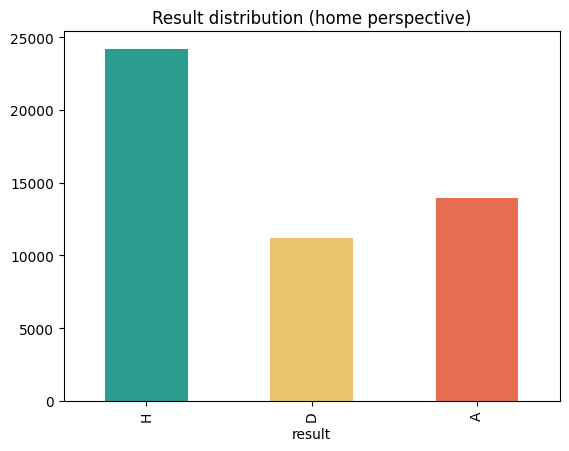

In [4]:
ax = played['result'].value_counts().reindex(['H','D','A']).plot(kind='bar', color=['#2a9d8f','#e9c46a','#e76f51'])
ax.set_title('Result distribution (home perspective)'); ax.set_xlabel('result'); plt.show()

## Goal distribution — is it Poisson-ish?
If team goals look roughly Poisson, a Poisson/Dixon-Coles goals model is well motivated.

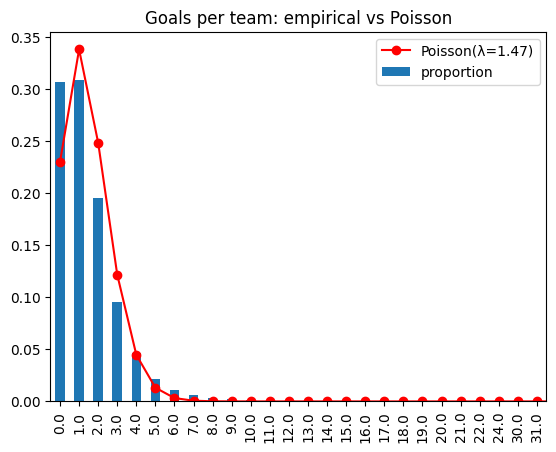

In [5]:
goals = pd.concat([played['home_score'], played['away_score']]).dropna()
ax = goals.value_counts(normalize=True).sort_index().plot(kind='bar')
lam = goals.mean()
import math
ks = range(0, int(goals.max())+1)
pois = [math.exp(-lam)*lam**k/math.factorial(k) for k in ks]
ax.plot(list(ks), pois, 'r-o', label=f'Poisson(\u03bb={lam:.2f})'); ax.legend()
ax.set_title('Goals per team: empirical vs Poisson'); plt.show()

## Home advantage over the decades
Has home advantage shrunk? (It has, historically.) Useful to know your model shouldn't treat 1950 like 2025.

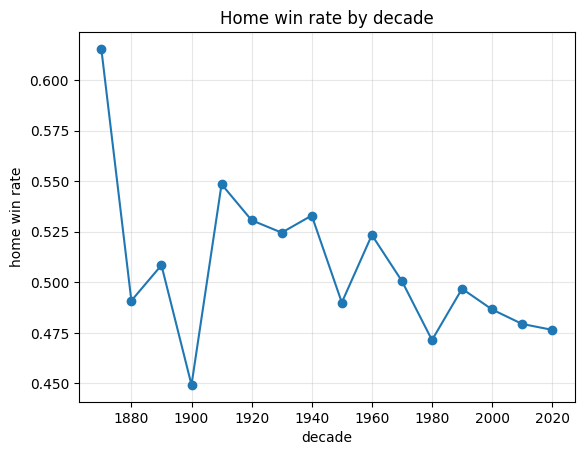

In [6]:
played['decade'] = (played['date'].dt.year // 10) * 10
hw = played.assign(home_win=(played['result']=='H').astype(int)).groupby('decade')['home_win'].mean()
ax = hw.plot(marker='o'); ax.set_ylabel('home win rate'); ax.set_title('Home win rate by decade'); ax.grid(alpha=.3); plt.show()

## Feature coverage & missingness
Form needs prior games; FIFA rank only exists from 1992. Check where features are present so a backtest fold doesn't silently train on mostly-NaN columns.

In [7]:
from wcpred import features as F
fcols = [c for c in F.feature_columns(df) if c in df.columns]
miss = df[fcols].isna().mean().sort_values(ascending=False)
print('Missing-rate by feature (top 15):'); print(miss.head(15).round(3))

Missing-rate by feature (top 15):
rank_diff             0.453
rank_points_diff      0.453
away_rank_points      0.429
away_rank             0.429
home_rank_points      0.425
home_rank             0.425
form_ga_10_diff       0.006
form_gd_10_diff       0.006
form_gf_5_diff        0.006
form_vs_elo_5_diff    0.006
form_ewm_ppg_diff     0.006
form_gf_10_diff       0.006
form_ppg_10_diff      0.006
rest_days_diff        0.006
form_ppg_5_diff       0.006
dtype: float64


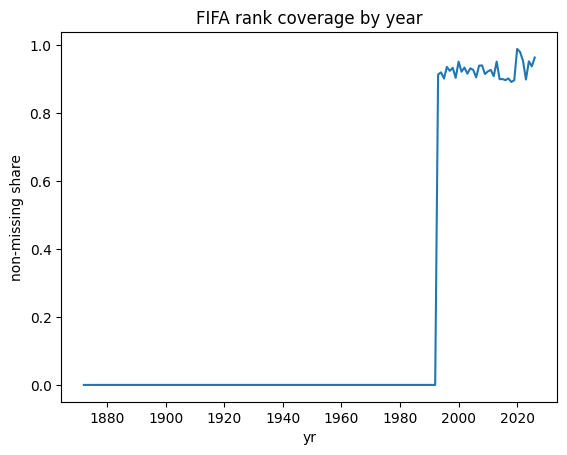

In [8]:
if 'home_rank' in df.columns:
    cov = df.assign(yr=df['date'].dt.year).groupby('yr')['home_rank'].apply(lambda s: s.notna().mean())
    ax = cov.plot(); ax.set_title('FIFA rank coverage by year'); ax.set_ylabel('non-missing share'); plt.show()
else:
    print('No rank column — FIFA ranking file was not downloaded.')

### Takeaways
- Confirm home advantage (~45% H / 27% D / 28% A) and that it **disappears on neutral ground** — a good sign the `neutral` flag is meaningful.
- Goals are close to Poisson → the Dixon-Coles / Poisson goals model is justified.
- Rank features start ~1992; form is NaN for a team's first games. Handle in the model (HistGradientBoosting tolerates NaN; linear models need imputation).